# Notebook 2: Classification - From Regression to Decision Boundaries

Ghana AI Talent Accelerator - Machine Learning Foundations

Speedykom Group GmbH

<a href="https://colab.research.google.com/github/Speedykom/GIZ_GhanaAI_Training_Materials/blob/main/05-machine-learning/intro_ML2.ipynb" target="_parent">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# 1. Regression vs. Classification

### The Fundamental Difference

In the previous notebook, we learned about **regression**—predicting
continuous values like house prices (₵250,000, ₵420,000, etc.).

**Classification** is different: we predict **categories** (labels)
instead of numbers.

| Regression                    | Classification                      |
|:------------------------------|:------------------------------------|
| House price: ₵250,000         | Email: spam vs. not spam            |
| Temperature: 25.3°C           | Image: cat vs. dog vs. bird         |
| Sales: 1,250 units            | Medical test: positive vs. negative |
| **Output**: Continuous number | **Output**: Category/label          |

### Real-World Classification Examples

**Business:**

-   Customer churn prediction (will they leave? Yes/No)
-   Credit card fraud detection (fraudulent? Yes/No)
-   Lead qualification (hot/warm/cold)

**Healthcare:**

-   Disease diagnosis (positive/negative)
-   Patient readmission risk (high/medium/low)
-   Treatment success prediction (success/failure)

**Technology:**

-   Spam detection (spam/ham)
-   Sentiment analysis (positive/negative/neutral)
-   Image recognition (what object is in this image?)

> **Why Classification is Everywhere**
>
> Most business decisions are **binary** (yes/no) or **categorical**
> (A/B/C). While regression helps us understand trends, classification
> helps us make decisions.

------------------------------------------------------------------------

# 2. The Iris Problem: A Gentle Introduction

Before tackling complex real-world problems, let’s start with a
**classic machine learning dataset** that’s perfect for learning
classification.

### What is the Iris Dataset?

The Iris dataset is one of the most famous datasets in machine learning.
It contains measurements of **150 iris flowers** from three different
species:

-   **Setosa**: 50 samples
-   **Versicolor**: 50 samples
-   **Virginica**: 50 samples

For each flower, we have **4 features**:

1.  **Sepal length** (in centimeters)
2.  **Sepal width** (in centimeters)
3.  **Petal length** (in centimeters)
4.  **Petal width** (in centimeters)

### Loading the Iris Dataset

In [1]:
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np

# Load the Iris dataset
iris = load_iris()

print("Iris Dataset Information:")
print(f"  Number of samples: {len(iris.data)}")
print(f"  Number of features: {len(iris.feature_names)}")
print(f"  Number of classes: {len(iris.target_names)}")
print(f"\nFeature names: {iris.feature_names}")
print(f"Target names (classes): {iris.target_names}")

Iris Dataset Information:
  Number of samples: 150
  Number of features: 4
  Number of classes: 3

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names (classes): ['setosa' 'versicolor' 'virginica']

### Exploring the Data

In [2]:
# Create DataFrame for easier exploration
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print("First 10 samples:")
print(df_iris.head(10))

print(f"\nSummary statistics:")
print(df_iris.describe())

print(f"\nSpecies distribution:")
print(df_iris['species'].value_counts())

First 10 samples:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   
7                5.0               3.4                1.5               0.2   
8                4.4               2.9                1.4               0.2   
9                4.9               3.1                1.5               0.1   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  
5  setosa  
6  setosa  
7  setosa  
8  s

### Visualizing the Iris Data

Let’s visualize the data to see how the different species are separated:

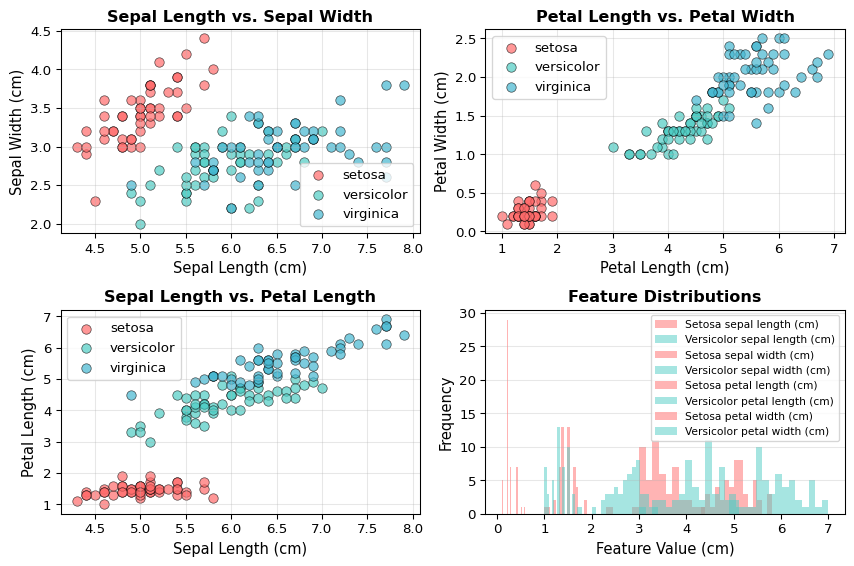

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(9, 6))

# Plot 1: Sepal Length vs Sepal Width
ax1 = axes[0, 0]
colors = {'setosa': '#FF6B6B', 'versicolor': '#4ECDC4', 'virginica': '#45B7D1'}
for species in iris.target_names:
    subset = df_iris[df_iris['species'] == species]
    ax1.scatter(subset['sepal length (cm)'], subset['sepal width (cm)'], 
               color=colors[species], label=species, alpha=0.7, s=50, edgecolor='black', linewidth=0.5)
ax1.set_xlabel('Sepal Length (cm)', fontsize=11)
ax1.set_ylabel('Sepal Width (cm)', fontsize=11)
ax1.set_title('Sepal Length vs. Sepal Width', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Petal Length vs. Petal Width
ax2 = axes[0, 1]
for species in iris.target_names:
    subset = df_iris[df_iris['species'] == species]
    ax2.scatter(subset['petal length (cm)'], subset['petal width (cm)'], 
               color=colors[species], label=species, alpha=0.7, s=50, edgecolor='black', linewidth=0.5)
ax2.set_xlabel('Petal Length (cm)', fontsize=11)
ax2.set_ylabel('Petal Width (cm)', fontsize=11)
ax2.set_title('Petal Length vs. Petal Width', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Sepal Length vs. Petal Length
ax3 = axes[1, 0]
for species in iris.target_names:
    subset = df_iris[df_iris['species'] == species]
    ax3.scatter(subset['sepal length (cm)'], subset['petal length (cm)'], 
               color=colors[species], label=species, alpha=0.7, s=50, edgecolor='black', linewidth=0.5)
ax3.set_xlabel('Sepal Length (cm)', fontsize=11)
ax3.set_ylabel('Petal Length (cm)', fontsize=11)
ax3.set_title('Sepal Length vs. Petal Length', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Feature Distribution by Species
ax4 = axes[1, 1]
features = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
for i, feature in enumerate(features):
    subset = df_iris[df_iris['species'] == 'setosa'][feature]
    ax4.hist(subset, bins=15, alpha=0.5, label=f'Setosa {feature}', color=colors['setosa'])
    subset = df_iris[df_iris['species'] == 'versicolor'][feature]
    ax4.hist(subset, bins=15, alpha=0.5, label=f'Versicolor {feature}', color=colors['versicolor'])
ax4.set_xlabel('Feature Value (cm)', fontsize=11)
ax4.set_ylabel('Frequency', fontsize=11)
ax4.set_title('Feature Distributions', fontsize=12, fontweight='bold')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Key Observations from Visualization

1.  **Setosa is easily separable**: Red points form a distinct cluster,
    especially in petal measurements
2.  **Versicolor and Virginica overlap**: Green and blue points are
    harder to separate
3.  **Petal measurements are more informative**: Petal length and width
    provide better separation than sepal measurements

> **Why Iris is Perfect for Learning**
>
> -   **Simple dataset**: Only 4 features and 3 classes
> -   **Clean data**: No missing values, well-balanced classes
> -   **Clear patterns**: Some classes are easily separable, others
>     overlap
> -   **Multi-class**: Teaches classification beyond binary problems
> -   **Visual**: Easy to plot and understand in 2D

### Training a Simple Classifier on Iris

Let’s train our first classification model using Logistic Regression:

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Prepare features and target
X_iris = iris.data
y_iris = iris.target

# Split into training and testing sets
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

# Scale features (important for Logistic Regression)
scaler_iris = StandardScaler()
X_train_iris_scaled = scaler_iris.fit_transform(X_train_iris)
X_test_iris_scaled = scaler_iris.transform(X_test_iris)

# Train Logistic Regression
logreg_iris = LogisticRegression(max_iter=200, random_state=42)
logreg_iris.fit(X_train_iris_scaled, y_train_iris)

# Make predictions
y_pred_iris = logreg_iris.predict(X_test_iris_scaled)

print("✅ Logistic Regression trained on Iris dataset!")
print(f"\nAccuracy: {accuracy_score(y_test_iris, y_pred_iris):.1%}")
print(f"\nClassification Report:")
print(classification_report(y_test_iris, y_pred_iris, 
                           target_names=iris.target_names))

✅ Logistic Regression trained on Iris dataset!

Accuracy: 93.3%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


### Visualizing Predictions

In [5]:
# Get predictions with probabilities
y_pred_iris = logreg_iris.predict(X_test_iris_scaled)
y_proba_iris = logreg_iris.predict_proba(X_test_iris_scaled)

# Create comparison DataFrame
results_iris = pd.DataFrame({
    'Actual': iris.target_names[y_test_iris],
    'Predicted': iris.target_names[y_pred_iris],
    'Correct': iris.target_names[y_test_iris] == iris.target_names[y_pred_iris]
})

print("Sample predictions (first 10):")
print(results_iris.head(10))

print(f"\nCorrect predictions: {results_iris['Correct'].sum()}/{len(results_iris)}")
print(f"Accuracy: {results_iris['Correct'].mean():.1%}")

Sample predictions (first 10):
       Actual   Predicted  Correct
0      setosa      setosa     True
1   virginica   virginica     True
2  versicolor  versicolor     True
3  versicolor  versicolor     True
4      setosa      setosa     True
5  versicolor  versicolor     True
6      setosa      setosa     True
7      setosa      setosa     True
8   virginica   virginica     True
9  versicolor  versicolor     True

Correct predictions: 28/30
Accuracy: 93.3%

------------------------------------------------------------------------

# 3. The Titanic Problem: Real-World Complexity

Now that we’ve learned classification with the Iris dataset, let’s
tackle a more complex, real-world problem: **predicting passenger
survival on the Titanic**.

### Loading the Dataset

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Titanic dataset
titanic = sns.load_dataset('titanic')

print("Titanic dataset shape:", titanic.shape)
print("\nFirst 5 passengers:")
print(titanic.head())

print(f"\nColumn names: {titanic.columns.tolist()}")

Titanic dataset shape: (891, 15)

First 5 passengers:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Column names: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

### Understanding the Data

In [7]:
# Key columns
key_columns = {
    'survived': 'Did the passenger survive? (0 = No, 1 = Yes)',
    'pclass': 'Passenger class (1 = First, 2 = Second, 3 = Third)',
    'sex': 'Gender (male/female)',
    'age': 'Age in years',
    'sibsp': 'Number of siblings/spouses aboard',
    'parch': 'Number of parents/children aboard',
    'fare': 'Ticket price',
    'embarked': 'Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)'
}

print("Key columns explained:")
for col, desc in key_columns.items():
    print(f"- {col}: {desc}")

Key columns explained:
- survived: Did the passenger survive? (0 = No, 1 = Yes)
- pclass: Passenger class (1 = First, 2 = Second, 3 = Third)
- sex: Gender (male/female)
- age: Age in years
- sibsp: Number of siblings/spouses aboard
- parch: Number of parents/children aboard
- fare: Ticket price
- embarked: Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)

### Exploratory Data Analysis

In [8]:
# Survival rate
survival_rate = titanic['survived'].mean()
print(f"Overall survival rate: {survival_rate:.1%}")

# Survival by class
survival_by_class = titanic.groupby('pclass')['survived'].agg(['count', 'mean'])
print(f"\nSurvival by passenger class:")
print(survival_by_class)

# Survival by gender
survival_by_sex = titanic.groupby('sex')['survived'].agg(['count', 'mean'])
print(f"\nSurvival by gender:")
print(survival_by_sex)

Overall survival rate: 38.4%

Survival by passenger class:
        count      mean
pclass                 
1         216  0.629630
2         184  0.472826
3         491  0.242363

Survival by gender:
        count      mean
sex                    
female    314  0.742038
male      577  0.188908

### Visualizing Survival Patterns

C:\Users\User1\AppData\Local\Temp\ipykernel_41084\4264276823.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\User1\AppData\Local\Temp\ipykernel_41084\4264276823.py:11: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



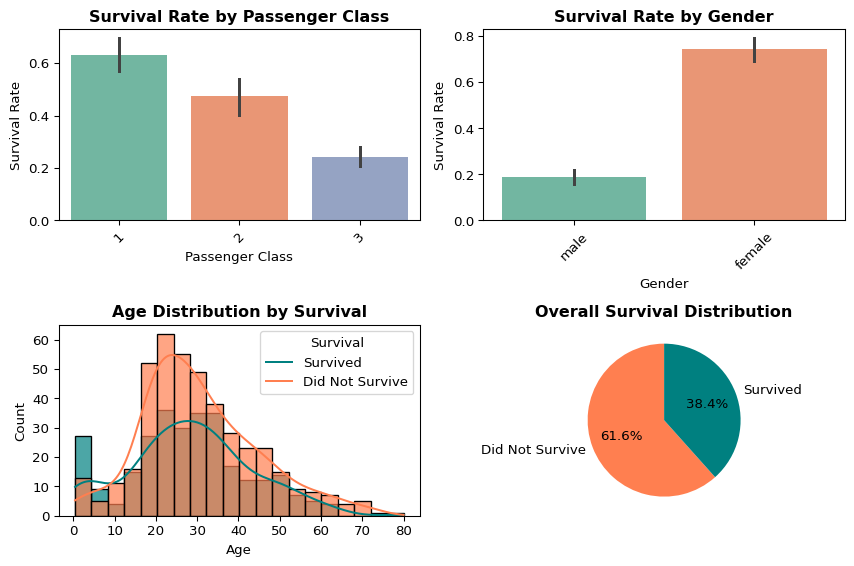

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(9, 6))

# 1. Survival by Class
sns.barplot(data=titanic, x='pclass', y='survived', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Survival Rate by Passenger Class', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Survival Rate')
axes[0, 0].set_xlabel('Passenger Class')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Survival by Gender
sns.barplot(data=titanic, x='sex', y='survived', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Survival Rate by Gender', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Survival Rate')
axes[0, 1].set_xlabel('Gender')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Age distribution by survival
sns.histplot(data=titanic, x='age', hue='survived', kde=True, ax=axes[1, 0], 
             bins=20, palette=['coral', 'teal'], alpha=0.7)
axes[1, 0].set_title('Age Distribution by Survival', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Age')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend(['Survived', 'Did Not Survive'], title='Survival')

# 4. Survival count
survival_counts = titanic['survived'].value_counts()
axes[1, 1].pie(survival_counts, labels=['Did Not Survive', 'Survived'], 
               autopct='%1.1f%%', colors=['coral', 'teal'], startangle=90)
axes[1, 1].set_title('Overall Survival Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Key Insights from EDA

-   **Class matters**: First-class passengers had ~62% survival rate
    vs. ~24% for third-class
-   **Gender matters**: Females had ~74% survival rate vs. ~19% for
    males
-   **Age matters**: Children and the elderly had different survival
    patterns
-   **Overall**: Only 38% of passengers survived

### Data Preprocessing

In [10]:
# Select relevant features
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
target = 'survived'

# Create a clean dataset
titanic_clean = titanic[features + [target]].copy()

# Check for missing values
print("Missing values before cleaning:")
print(titanic_clean.isnull().sum())

# Handle missing values
# - Age: Fill with median
# - Embarked: Fill with mode
titanic_clean['age'] = titanic_clean['age'].fillna(titanic_clean['age'].median())
titanic_clean['embarked'] = titanic_clean['embarked'].fillna(titanic_clean['embarked'].mode()[0])

# One-hot encode categorical variables
titanic_clean = pd.get_dummies(titanic_clean, columns=['sex', 'embarked'], drop_first=True)

print(f"\nMissing values after cleaning:")
print(titanic_clean.isnull().sum())

print(f"\nFinal columns: {titanic_clean.columns.tolist()}")
print(f"\nClean dataset shape: {titanic_clean.shape}")

Missing values before cleaning:
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
survived      0
dtype: int64

Missing values after cleaning:
pclass        0
age           0
sibsp         0
parch         0
fare          0
survived      0
sex_male      0
embarked_Q    0
embarked_S    0
dtype: int64

Final columns: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'survived', 'sex_male', 'embarked_Q', 'embarked_S']

Clean dataset shape: (891, 9)

### Prepare for Machine Learning

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split features and target
X = titanic_clean.drop('survived', axis=1)
y = titanic_clean['survived']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train_scaled.shape[0]} samples")
print(f"Test set size: {X_test_scaled.shape[0]} samples")
print(f"Number of features: {X_train_scaled.shape[1]}")

Training set size: 712 samples
Test set size: 179 samples
Number of features: 8

------------------------------------------------------------------------

# 4. Logistic Regression

### Why Linear Regression Fails for Classification

If we try to use linear regression for classification, we get a problem:

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score

# Try linear regression (BAD approach for classification)
linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train)
linreg_pred = linreg.predict(X_test_scaled)

# Show some predictions
print("Linear regression predictions (BAD for classification):")
print(f"Sample predictions: {linreg_pred[:5]}")
print(f"Unique prediction values: {np.unique(linreg_pred.round(1))}")

# The problem: values outside [0, 1]
print(f"\nProblem: Some predictions are outside [0, 1]: {np.any((linreg_pred < 0) | (linreg_pred > 1))}")

Linear regression predictions (BAD for classification):
Sample predictions: [0.12091262 0.24665294 0.14287467 0.86649054 0.7188075 ]
Unique prediction values: [-0.1  0.   0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.9  1. ]

Problem: Some predictions are outside [0, 1]: True

**The Issue**: Linear regression can predict values like -0.3 or 1.7,
which don’t make sense for probability!

### The Solution: The Sigmoid Function

The sigmoid function “squashes” any value into the range \[0, 1\]:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Let’s visualize it:

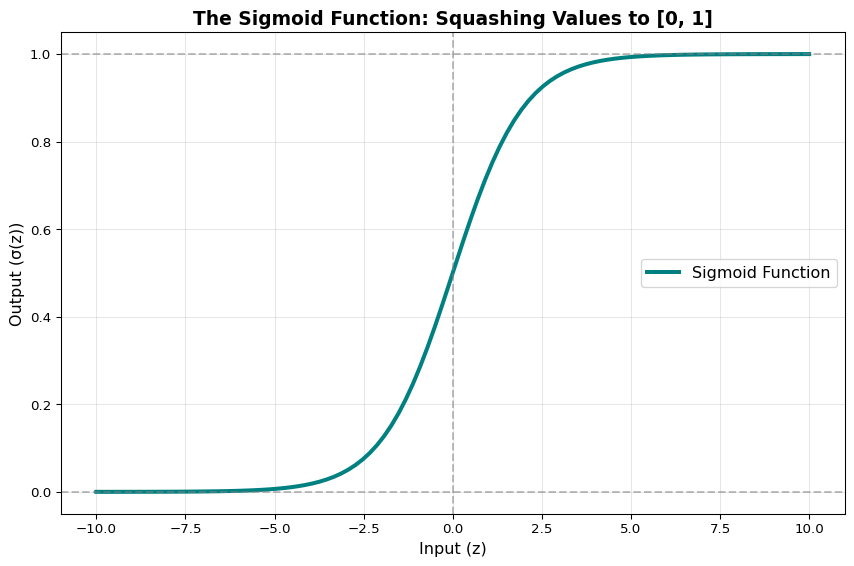

In [13]:
z = np.linspace(-10, 10, 100)
sigmoid = 1 / (1 + np.exp(-z))

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(z, sigmoid, color='teal', linewidth=3, label='Sigmoid Function')

ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

ax.set_xlabel('Input (z)', fontsize=12)
ax.set_ylabel('Output (σ(z))', fontsize=12)
ax.set_title('The Sigmoid Function: Squashing Values to [0, 1]', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

**Key properties:**

-   Input = -10 → Output ≈ 0
-   Input = 0 → Output = 0.5
-   Input = 10 → Output ≈ 1

### Logistic Regression Formula

The logistic regression model is:

$$P(y=1) = \sigma(b + w_1x_1 + w_2x_2 + \dots)$$

Where:

-   $P(y=1)$ = probability of class 1 (survival)
-   $\sigma$ = sigmoid function
-   $b, w_1, w_2, \dots$ = model parameters
-   $x_1, x_2, \dots$ = features

> **Binary vs. Multi-Class Classification**
>
> **Binary Classification** (like Titanic):
>
> -   Two classes: 0 (no) or 1 (yes)
> -   One sigmoid function gives probability of class 1
> -   $P(y=0) = 1 - P(y=1)$
>
> **Multi-Class Classification** (like Iris):
>
> -   Multiple classes: 3 species
> -   Logistic Regression uses **One-vs-Rest** strategy
> -   Trains multiple binary classifiers, one for each class
> -   Final prediction = class with highest probability

### Logistic Regression on Iris (Multi-Class)

We already trained Logistic Regression on the Iris dataset earlier.
Let’s explore it in more detail:

In [14]:
# Revisit Iris Logistic Regression
print(f"Logistic Regression on Iris Dataset:")
print(f"  Number of classes: {len(logreg_iris.classes_)}")
print(f"  Classes: {iris.target_names}")

# Coefficients for each class
print(f"\nModel coefficients (weights) for each class:")
for i, class_name in enumerate(iris.target_names):
    print(f"\n{class_name}:")
    for j, feature in enumerate(iris.feature_names):
        print(f"  {feature}: {logreg_iris.coef_[i][j]:.3f}")

print(f"\nIntercepts for each class:")
for i, class_name in enumerate(iris.target_names):
    print(f"  {class_name}: {logreg_iris.intercept_[i]:.3f}")

Logistic Regression on Iris Dataset:
  Number of classes: 3
  Classes: ['setosa' 'versicolor' 'virginica']

Model coefficients (weights) for each class:

setosa:
  sepal length (cm): -1.089
  sepal width (cm): 1.024
  petal length (cm): -1.799
  petal width (cm): -1.686

versicolor:
  sepal length (cm): 0.536
  sepal width (cm): -0.360
  petal length (cm): -0.204
  petal width (cm): -0.808

virginica:
  sepal length (cm): 0.553
  sepal width (cm): -0.664
  petal length (cm): 2.003
  petal width (cm): 2.494

Intercepts for each class:
  setosa: -0.306
  versicolor: 1.909
  virginica: -1.603

### Logistic Regression on Titanic (Binary)

Now let’s train Logistic Regression on the Titanic dataset:

In [15]:
# Train logistic regression on Titanic
logreg_titanic = LogisticRegression(random_state=42, max_iter=1000)
logreg_titanic.fit(X_train_scaled, y_train)

# Make predictions
y_pred_titanic = logreg_titanic.predict(X_test_scaled)
y_pred_proba_titanic = logreg_titanic.predict_proba(X_test_scaled)

print("✅ Logistic Regression trained on Titanic dataset!")

✅ Logistic Regression trained on Titanic dataset!

### Understanding Predictions: Iris vs. Titanic

In [16]:
print("=== IRIS DATASET (Multi-Class) ===\n")
print("Sample predictions for Iris:")
for i in range(5):
    actual = iris.target_names[y_test_iris[i]]
    predicted = iris.target_names[y_pred_iris[i]]
    confidence = y_proba_iris[i].max()
    print(f"  Actual: {actual}, Predicted: {predicted}, Confidence: {confidence:.2%}")

print(f"\n=== TITANIC DATASET (Binary) ===\n")
print("Sample predictions for Titanic:")
results_titanic = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted Class': y_pred_titanic,
    'Probability (Class 0)': y_pred_proba_titanic[:, 0],
    'Probability (Class 1)': y_pred_proba_titanic[:, 1]
})
print(results_titanic.head(10).round(3))

=== IRIS DATASET (Multi-Class) ===

Sample predictions for Iris:
  Actual: setosa, Predicted: setosa, Confidence: 97.88%
  Actual: virginica, Predicted: virginica, Confidence: 62.70%
  Actual: versicolor, Predicted: versicolor, Confidence: 84.25%
  Actual: versicolor, Predicted: versicolor, Confidence: 89.46%
  Actual: setosa, Predicted: setosa, Confidence: 98.85%

=== TITANIC DATASET (Binary) ===

Sample predictions for Titanic:
   Actual  Predicted Class  Probability (Class 0)  Probability (Class 1)
0       1                0                  0.893                  0.107
1       0                0                  0.783                  0.217
2       0                0                  0.871                  0.129
3       1                1                  0.109                  0.891
4       1                1                  0.248                  0.752
5       1                1                  0.064                  0.936
6       1                1                  0.309      

**Key Differences:**

| Aspect | Iris (Multi-Class) | Titanic (Binary) |
|:-----------------------|:-----------------------|:-----------------------|
| **Number of classes** | 3 (Setosa, Versicolor, Virginica) | 2 (Did Not Survive, Survived) |
| **Output shape** | 3 probabilities per sample | 2 probabilities per sample |
| **Decision rule** | Class with highest probability | Class 1 if $P(y=1) > 0.5$ |
| **Interpretation** | Which species is most likely? | Will they survive or not? |

### Training a Logistic Regression Model

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train logistic regression
logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train_scaled, y_train)

# Make predictions
y_pred = logreg.predict(X_test_scaled)
y_pred_proba = logreg.predict_proba(X_test_scaled)

print("✅ Logistic regression model trained!")

✅ Logistic regression model trained!

### Understanding Predictions

In [18]:
# Show some predictions
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted Class': y_pred,
    'Probability (Class 0)': y_pred_proba[:, 0],
    'Probability (Class 1)': y_pred_proba[:, 1]
})

print("Sample predictions (first 10):")
print(results.head(10).round(3))

Sample predictions (first 10):
   Actual  Predicted Class  Probability (Class 0)  Probability (Class 1)
0       1                0                  0.893                  0.107
1       0                0                  0.783                  0.217
2       0                0                  0.871                  0.129
3       1                1                  0.109                  0.891
4       1                1                  0.248                  0.752
5       1                1                  0.064                  0.936
6       1                1                  0.309                  0.691
7       0                0                  0.913                  0.087
8       1                1                  0.237                  0.763
9       1                1                  0.074                  0.926

**Key observations:**

-   `Predicted Class`: Either 0 or 1 (did not survive / survived)
-   `Probability (Class 1)`: How confident the model is about survival
-   Threshold is typically 0.5: if probability \> 0.5 → predict class 1

### Evaluating Classification Models

In [19]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.1%}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(cm)

# Classification Report
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Did Not Survive', 'Survived']))

Accuracy: 81.0%

Confusion Matrix:
[[90 15]
 [19 55]]

Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.83      0.86      0.84       105
       Survived       0.79      0.74      0.76        74

       accuracy                           0.81       179
      macro avg       0.81      0.80      0.80       179
   weighted avg       0.81      0.81      0.81       179


### Visualizing the Confusion Matrix

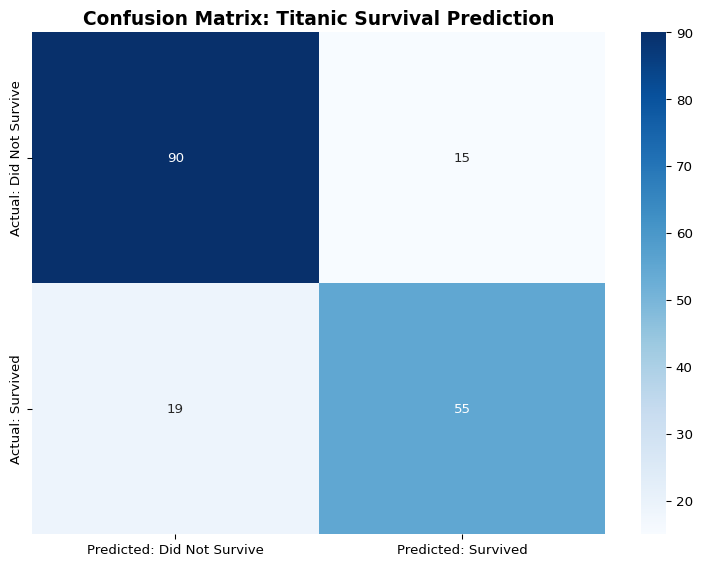

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Predicted: Did Not Survive', 'Predicted: Survived'],
            yticklabels=['Actual: Did Not Survive', 'Actual: Survived'])

ax.set_title('Confusion Matrix: Titanic Survival Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpreting the Confusion Matrix

|                 | Predicted: No          | Predicted: Yes         |
|:----------------|:-----------------------|:-----------------------|
| **Actual: No**  | **True Negative (TN)** | False Positive (FP)    |
| **Actual: Yes** | False Negative (FN)    | **True Positive (TP)** |

**Metrics derived from the confusion matrix:**

-   **Accuracy**: (TP + TN) / Total - Overall correctness
-   **Precision**: TP / (TP + FP) - Of predicted positive, how many are
    actually positive?
-   **Recall**: TP / (TP + FN) - Of actual positive, how many did we
    catch?
-   **F1-Score**: Harmonic mean of precision and recall

> **When Accuracy Can Be Misleading**
>
> If 90% of passengers did NOT survive, a model that always predicts
> “did not survive” would have 90% accuracy—but it’s useless! Always
> look at precision and recall too.

### Making Sense of Metrics: A Local Analogy

To truly understand these metrics, let’s use an example everyone knows:
**A Malaria Rapid Diagnostic Test (RDT) at a local clinic.**

Imagine 100 people visit the clinic today.

-   **10 people** *actually* have malaria.
-   **90 people** just have a common cold or flu.

The clinic uses a new AI-powered Malaria Test. Here are the results:

-   **True Positive (TP = 8):** 8 people have malaria, and the test
    correctly says “Positive”. (A correct catch!)
-   **True Negative (TN = 80):** 80 people just have a cold, and the
    test correctly says “Negative”. (A correct clearance!)
-   **False Positive (FP = 10):** 10 people just have a cold, but the
    test falsely alarms and says “Positive”. (False Alarm!)
-   **False Negative (FN = 2):** 2 people actually have malaria, but the
    test misses it and says “Negative”. (Missed Diagnosis!)

Now, let’s calculate the metrics using this clinic data:

**1. Accuracy: “Is this test generally right?”**

-   **Formula:** $\frac{TP + TN}{Total}$
-   **Calculation:** $\frac{8 + 80}{100} = \frac{88}{100} = 88\%$
-   *Analogy:* The test is correct 88% of the time. Sounds great, right?
    But wait…

**2. Precision: “When the test screams ‘Malaria!’, how often is it
actually right?”**

-   **Formula:** $\frac{TP}{TP + FP}$
-   **Calculation:** $\frac{8}{8 + 10} = \frac{8}{18} = 44.4\%$
-   *Analogy:* If the test says you have malaria, there is less than a
    50% chance you actually have it! The clinic is making a lot of
    healthy people buy expensive malaria drugs they don’t need.

**3. Recall (Sensitivity): “Out of everyone who is ACTUALLY sick, how
many did we catch?”**

-   **Formula:** $\frac{TP}{TP + FN}$
-   **Calculation:** $\frac{8}{8 + 2} = \frac{8}{10} = 80\%$
-   *Analogy:* The test successfully found 80% of the sick patients. But
    it sent 2 sick people home with just paracetamol, putting their
    lives in danger.

**4. F1-Score: “Finding the Perfect Balance”**

-   **Formula:**
    $2 \times \frac{Precision \times Recall}{Precision + Recall}$
-   **Calculation:**
    $2 \times \frac{0.444 \times 0.80}{0.444 + 0.80} = 2 \times \frac{0.355}{1.244} = 57\%$
-   *Analogy:* F1 is the “harmonic mean” of Precision and Recall. It
    penalizes models that are extreme on one side.

### How to Choose: Precision vs. Recall vs. F1?

In the real world, you usually have to trade one for the other. How do
you choose? **It depends on the cost of being wrong.**

**Scenario A: Optimize for RECALL (Catch everything!)**

-   *Example:* **Malaria or Disease Testing**
-   *Why?* A False Negative (sending a sick patient home) could be
    fatal. A False Positive (giving someone harmless anti-malarial
    medication for a cold) is merely an inconvenience. Therefore, you
    want a test with **High Recall**, even if it means sacrificing some
    precision. You want to catch *every single* possible case.

**Scenario B: Optimize for PRECISION (Be absolutely sure!)**

-   *Example:* **Mobile Money (MoMo) Fraud Detection**
-   *Why?* Imagine an AI that blocks MoMo accounts suspected of fraud.
    If you have a False Positive (blocking an innocent market woman from
    receiving money for her goods), she will be furious and lose trust
    in the network. Here, you only want to block an account if you are
    *absolutely certain* it’s fraudulent. You want **High Precision**,
    even if it means missing a few clever scammers (False Negatives).

**Scenario C: Optimize for F1-Score (Find the Perfect Balance)**

-   *Example:* **Sorting Premium Cocoa Beans for Export**
-   *Why?* Imagine a machine sorting good cocoa beans from bad ones.
    -   If you throw away good beans thinking they are bad (False
        Positive), the farmer loses hard-earned money.
    -   If you let bad, rotten beans slip through to the export batch
        (False Negative), the entire shipping container might get
        rejected at the port!
-   Because *both* mistakes are highly costly, you cannot afford to just
    optimize Precision or just Recall. You need a metric that perfectly
    balances both.

------------------------------------------------------------------------

# 5. Decision Trees

### The Concept: A Visual, Intuitive Classifier

A decision tree is like a **flowchart** for making decisions. It asks a
series of yes/no questions to classify data.

**Example for Iris Classification:**

``` text
Is the petal length <= 2.45 cm?
├── Yes → Predict: Setosa (100% certainty)
└── No → Is the petal width <= 1.75 cm?
    ├── Yes → Predict: Versicolor
    └── No → Predict: Virginica
```

**Example for Titanic Classification:**

``` text
Is the passenger male?
├── Yes → Predict: Did Not Survive (high probability)
└── No → Is the passenger in first class?
    ├── Yes → Predict: Survived
    └── No → Check age and fare
```

### Training Decision Trees on Both Datasets

Let’s train Decision Trees on both Iris and Titanic datasets to see how
they work:

In [21]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

# ==================== IRIS DATASET ====================
print("=== DECISION TREE ON IRIS DATASET ===\n")

# Train decision tree on Iris
dtree_iris = DecisionTreeClassifier(random_state=42, max_depth=3)
dtree_iris.fit(X_train_iris_scaled, y_train_iris)

# Make predictions
y_pred_dtree_iris = dtree_iris.predict(X_test_iris_scaled)

print(f"Decision Tree Accuracy on Iris: {accuracy_score(y_test_iris, y_pred_dtree_iris):.1%}")

# ==================== TITANIC DATASET ====================
print(f"\n=== DECISION TREE ON TITANIC DATASET ===\n")

# Train decision tree on Titanic
dtree_titanic = DecisionTreeClassifier(random_state=42, max_depth=3)
dtree_titanic.fit(X_train, y_train)

# Make predictions
y_pred_dtree_titanic = dtree_titanic.predict(X_test)

print(f"Decision Tree Accuracy on Titanic: {accuracy_score(y_test, y_pred_dtree_titanic):.1%}")

=== DECISION TREE ON IRIS DATASET ===

Decision Tree Accuracy on Iris: 96.7%

=== DECISION TREE ON TITANIC DATASET ===

Decision Tree Accuracy on Titanic: 79.9%

### Visualizing Decision Tree: Titanic Survival

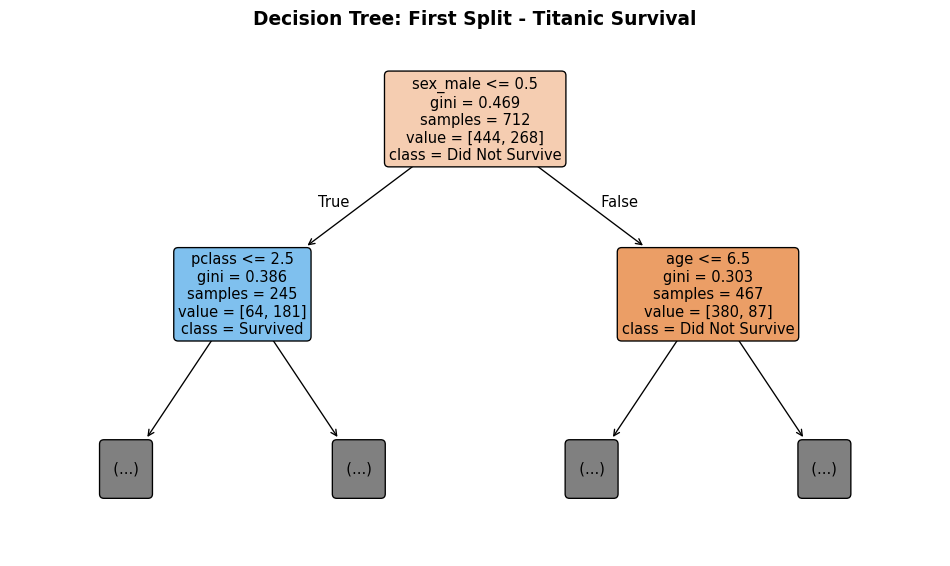

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot Titanic tree - only first split
feature_names = X.columns.tolist()
class_names_titanic = ['Did Not Survive', 'Survived']

plot_tree(dtree_titanic, feature_names=feature_names, class_names=class_names_titanic,
          filled=True, rounded=True, fontsize=11, max_depth=1, ax=ax)

ax.set_title('Decision Tree: First Split - Titanic Survival', 
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### Interpreting the Tree

-   **Root Node**: The first decision point (most important feature)
-   **Edges**: Branches (True/False paths)
-   **Leaves**: Final predictions at this split level
-   **Color**: Blue = more “Survived” predictions, Orange = more “Did
    Not Survive”

**Key insight from first split:** The tree chooses the **most
informative feature** for the first split—typically `sex_male` for
Titanic, showing that gender is the strongest predictor of survival.

This simple visualization demonstrates how decision trees make
interpretable, rule-based decisions by asking a series of yes/no
questions.

### The Overfitting Problem

In [23]:
# Compare trees with different depths
depths = [3, 5, 10, None]
accuracies = []

for depth in depths:
    dt = DecisionTreeClassifier(random_state=42, max_depth=depth)
    dt.fit(X_train, y_train)
    acc = dt.score(X_test, y_test)
    accuracies.append(acc)
    print(f"Depth {depth}: {acc:.1%}")

print(f"\nHighest accuracy: {max(accuracies):.1%} at depth {depths[accuracies.index(max(accuracies))]}")

Depth 3: 79.9%
Depth 5: 79.9%
Depth 10: 79.3%
Depth None: 78.2%

Highest accuracy: 79.9% at depth 3

**The tradeoff:**

-   **Shallow tree** (depth=3): Simple, interpretable, may underfit
-   **Deep tree** (depth=10+): Complex, can memorize data, may overfit

### Overfitting Visualization

In [24]:
# Train two extreme trees
dt_shallow = DecisionTreeClassifier(random_state=42, max_depth=2)
dt_deep = DecisionTreeClassifier(random_state=42, max_depth=15)

dt_shallow.fit(X_train, y_train)
dt_deep.fit(X_train, y_train)

acc_shallow = dt_shallow.score(X_test, y_test)
acc_deep = dt_deep.score(X_test, y_test)

print(f"Shallow tree (depth=2): {acc_shallow:.1%}")
print(f"Deep tree (depth=15): {acc_deep:.1%}")

# Visualize the deep tree (it will be huge!)
if dt_deep.tree_.max_depth > 20:
    print(f"\n⚠️  Warning: Deep tree has {dt_deep.tree_.max_depth} levels!")

Shallow tree (depth=2): 76.5%
Deep tree (depth=15): 77.7%

### Controlling Overfitting

In [25]:
# Key parameters to prevent overfitting
dt_pruned = DecisionTreeClassifier(
    random_state=42,
    max_depth=5,          # Limit tree depth
    min_samples_split=10, # Minimum samples to split a node
    min_samples_leaf=5    # Minimum samples in a leaf
)

dt_pruned.fit(X_train, y_train)
acc_pruned = dt_pruned.score(X_test, y_test)

print(f"Pruned tree accuracy: {acc_pruned:.1%}")
print(f"Tree depth: {dt_pruned.tree_.max_depth}")
print(f"Number of leaves: {dt_pruned.tree_.n_leaves}")

Pruned tree accuracy: 80.4%
Tree depth: 5
Number of leaves: 21

> **Decision Tree Pros and Cons**
>
> **Pros:**
>
> -   ✅ Highly interpretable (you can explain decisions)
> -   ✅ Handles both numerical and categorical data
> -   ✅ No feature scaling required
> -   ✅ Captures non-linear relationships
>
> **Cons:**
>
> -   ❌ Prone to overfitting (without pruning)
> -   ❌ Can be unstable (small data changes = different tree)
> -   ❌ May not achieve highest accuracy

------------------------------------------------------------------------

# 6. Model Comparison: Logistic Regression vs. Decision Tree

In [26]:
from sklearn.model_selection import cross_val_score

# Train both models
logreg = LogisticRegression(random_state=42, max_iter=1000)
dtree = DecisionTreeClassifier(random_state=42, max_depth=5)

logreg.fit(X_train_scaled, y_train)
dtree.fit(X_train, y_train)

# Cross-validation scores
logreg_cv = cross_val_score(logreg, X_train_scaled, y_train, cv=5)
dtree_cv = cross_val_score(dtree, X_train, y_train, cv=5)

print("Logistic Regression:")
print(f"  Test accuracy: {accuracy_score(y_test, logreg.predict(X_test_scaled)):.1%}")
print(f"  CV accuracy: {logreg_cv.mean():.1%} (±{logreg_cv.std():.1%})")

print(f"\nDecision Tree:")
print(f"  Test accuracy: {accuracy_score(y_test, dtree.predict(X_test)):.1%}")
print(f"  CV accuracy: {dtree_cv.mean():.1%} (±{dtree_cv.std():.1%})")

Logistic Regression:
  Test accuracy: 81.0%
  CV accuracy: 78.9% (±2.8%)

Decision Tree:
  Test accuracy: 79.9%
  CV accuracy: 80.2% (±1.7%)

### When to Use Which Model?

| Scenario | Recommended Model | Why |
|:-----------------------|:-----------------------|:-----------------------|
| Need interpretability | Decision Tree | Can explain each decision |
| Linear relationships | Logistic Regression | Simpler, more stable |
| Many features | Logistic Regression | Handles high dimensions better |
| Non-linear patterns | Decision Tree | Captures complex interactions |
| Need probabilities | Logistic Regression | Provides well-calibrated probabilities |
| Quick baseline | Decision Tree | Fast to train, easy to understand |

------------------------------------------------------------------------

# 7. Summary & Key Takeaways

### Classification vs. Regression

| Aspect         | Regression               | Classification                  |
|:---------------|:-------------------------|:--------------------------------|
| **Output**     | Continuous number        | Category/label                  |
| **Examples**   | House price, temperature | Spam detection, diagnosis       |
| **Formula**    | $\hat{y} = b + wx$       | $P(y=1) = \sigma(b + wx)$       |
| **Evaluation** | MSE, R²                  | Accuracy, Precision, Recall, F1 |

### Key Classification Concepts

| Concept | Description | Example |
|:-----------------------|:-----------------------|:-----------------------|
| **Sigmoid Function** | Squashes values to \[0, 1\] | Converts raw scores to probabilities |
| **Confusion Matrix** | Shows prediction errors | TP, TN, FP, FN |
| **Accuracy** | Overall correctness | 80% of predictions are correct |
| **Precision** | Of predicted positive, how many are actually positive | 90% of spam emails were actually spam |
| **Recall** | Of actual positive, how many did we catch | We caught 75% of all spam emails |
| **F1-Score** | Balance of precision and recall | Harmonic mean |

### Model Comparison

| Model | Best For | Pros | Cons |
|:-----------------|:-----------------|:-----------------|:-----------------|
| **Logistic Regression** | Baseline, linear relationships | Probabilistic, stable, interpretable | Can’t capture non-linear patterns |
| **Decision Tree** | Interpretability, non-linear patterns | Visual, handles categorical data | Prone to overfitting |

### Professional Checklist

-   ✅ Understand the difference between regression and classification
-   ✅ Can explain why sigmoid function is needed
-   ✅ Can interpret confusion matrix and derive metrics
-   ✅ Know when accuracy can be misleading
-   ✅ Understand overfitting and how to prevent it
-   ✅ Can choose the right model for the problem

------------------------------------------------------------------------

# 8. Practice Exercise

Your turn! Build classifiers on both Iris and Titanic datasets to
solidify your understanding.

### Exercise A: Iris Multi-Class Classification

In [27]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load Iris dataset
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Split data
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

# Your task:
# 1. Train Logistic Regression on Iris dataset
# 2. Train Decision Tree on Iris dataset
# 3. Compare accuracy of both models
# 4. Which model performs better and why?
# 5. Try different max_depth values (2, 3, 5, 10) for decision tree

# Hint: Use accuracy_score() and classification_report()

### Exercise B: Titanic Binary Classification

In [28]:
import seaborn as sns

# Load Titanic dataset
titanic = sns.load_dataset('titanic')

# Your task:
# 1. Explore the data (survival rates by class, gender, age)
# 2. Visualize survival patterns (bar plots, histograms)
# 3. Preprocess data (handle missing values, one-hot encoding)
# 4. Train Logistic Regression
# 5. Train Decision Tree
# 6. Compare models using confusion matrices and classification reports
# 7. Which features are most important for survival prediction?

# Hint: Use sns.barplot() and sns.heatmap() for visualizations

### Exercise C: Comparison Challenge

In [29]:
# Compare Iris vs. Titanic:
# - Which dataset is easier to classify?
# - Which model type (Logistic Regression vs. Decision Tree) works better on each dataset?
# - How does multi-class classification differ from binary classification?
# - What are the key differences in feature importance between datasets?

------------------------------------------------------------------------

# 9. What’s Next?

Congratulations! You’ve learned the fundamentals of classification. In
the next notebook, we’ll explore **ensemble methods**—combining multiple
models to achieve even better performance.

**Next Module: Notebook 3: Ensemble Methods - The Power of Many**

-   Random Forest: Bagging many decision trees
-   Gradient Boosting: Learning from mistakes
-   XGBoost: State-of-the-art ensemble method
-   Hyperparameter tuning with GridSearchCV
-   Complete ML pipeline from data to deployment

## You’ve Learned

✅ The difference between regression and classification

✅ How logistic regression works and why we need the sigmoid function

✅ How to build and interpret decision trees

✅ How to evaluate classification models (accuracy, precision, recall,
F1)

✅ When to use logistic regression vs. decision trees

✅ The overfitting problem and how to prevent it